Loan prediction using Decision Tree Algorithm

1. Pre-process the data (to fit in decision tree)

In [ ]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder

data = pd.read_csv("loan_data.csv")

le = LabelEncoder()

for col in ["Gender", "Married", "Education", "Self_Employed"]:
    data[col] = le.fit_transform(data[col])

data = pd.get_dummies(data, columns=["Property_Area"], drop_first=True)

print("Encoded Dataset Sample:")
print(data.head())

data.to_csv("loan_data_preprocessed.csv", index=False)

✅ Encoded Dataset Sample:
  Applicant_ID  Gender  Married  Dependents  Education  Self_Employed  \
0       A10000       1        1           1          0              0   
1       A10001       0        1           0          0              1   
2       A10002       0        1           0          1              1   
3       A10003       1        1           1          0              0   
4       A10004       1        1           0          0              0   

   ApplicantIncome  CoapplicantIncome  LoanAmount  Loan_Amount_Term  \
0            49714              26464      124343               360   
1            68109              25717      196526               240   
2            59379               6000      201542               480   
3            37929               2594      138494               300   
4            76806              17295      322818               360   

   Credit_History  Employment_Length  Age  Loan_Status  \
0               1                 18   23         

2. Import the necessary libraries

In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

3. Load the dataset.

In [3]:
df = pd.read_csv("loan_data_preprocessed.csv")
df.head()

,Applicant_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Employment_Length,Age,Loan_Status,Property_Area_Semiurban,Property_Area_Urban
0,A10000,1,1,1,0,0,49714,26464,124343,360,1,18,23,1,False,True
1,A10001,0,1,0,0,1,68109,25717,196526,240,1,26,53,1,True,False
2,A10002,0,1,0,1,1,59379,6000,201542,480,1,6,51,0,False,True
3,A10003,1,1,1,0,0,37929,2594,138494,300,1,17,32,1,True,False
4,A10004,1,1,0,0,0,76806,17295,322818,360,1,26,23,1,False,True


4. Extract features and label; split the dataset into train and test datasets

In [9]:
X = df.drop(columns=["Loan_Status", "Applicant_ID"], axis=1)
y = df["Loan_Status"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=45, stratify=y)

In [24]:
X.columns.tolist()

['Gender',
 'Married',
 'Dependents',
 'Education',
 'Self_Employed',
 'ApplicantIncome',
 'CoapplicantIncome',
 'LoanAmount',
 'Loan_Amount_Term',
 'Credit_History',
 'Employment_Length',
 'Age',
 'Property_Area_Semiurban',
 'Property_Area_Urban']

5. Train the Decision Tree Classifier Model with training data

In [10]:
dt_model = DecisionTreeClassifier(random_state=45)
dt_model.fit(X_train, y_train)

DecisionTreeClassifier(random_state=45)

6. Check the model performance - accuracy, precision, recall, F1 score

In [13]:
y_pred = dt_model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)
report = classification_report(y_test, y_pred)

print(f"Model Accuracy: {accuracy:.2f}")
print("\nConfusion Matrix: ")
print(cm)
print("\nClassification Report:\n", report)

Model Accuracy: 0.86

Confusion Matrix: 
[[ 704  146]
 [ 128 1022]]

Classification Report:
               precision    recall  f1-score   support

           0       0.85      0.83      0.84       850
           1       0.88      0.89      0.88      1150

    accuracy                           0.86      2000
   macro avg       0.86      0.86      0.86      2000
weighted avg       0.86      0.86      0.86      2000



7. Visualize the decision tree 

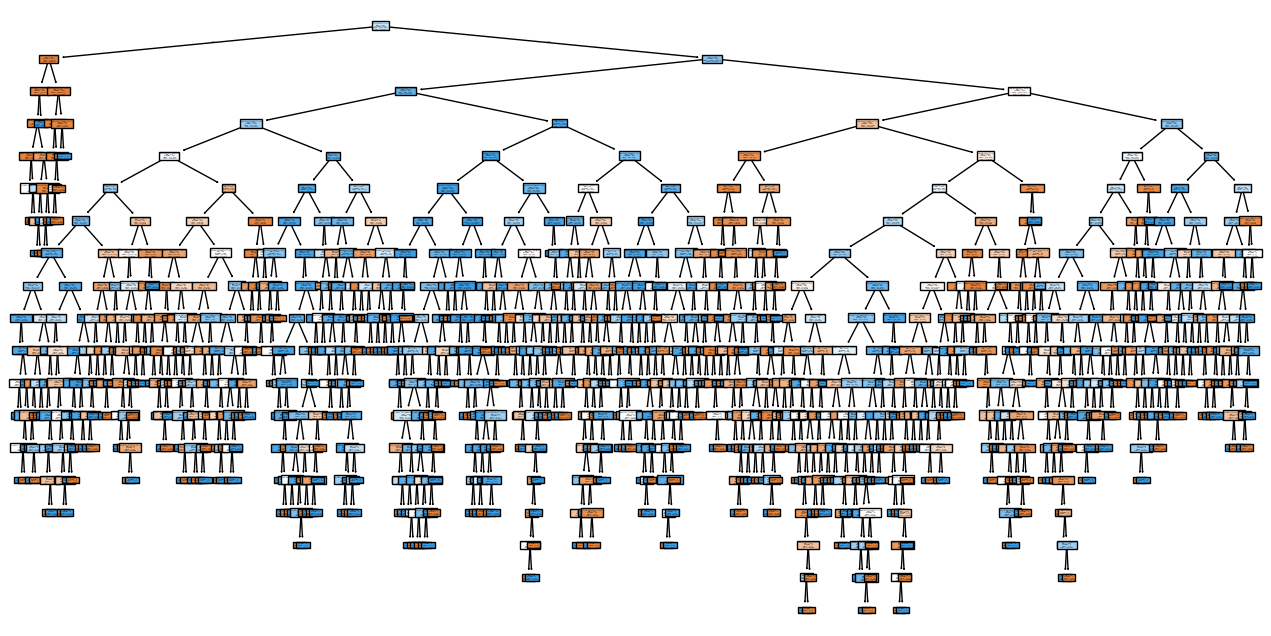

In [15]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(16,8))
plot_tree(dt_model, filled=True, feature_names=X.columns, class_names=["Rejected", "Approved"])
plt.show()


8. Control overfitting by limiting the tree's complexity

In [27]:
dt_tuned = DecisionTreeClassifier(
    max_depth=7,
    min_samples_split=75,
    min_samples_leaf=40,
    random_state=45
)

dt_tuned.fit(X_train, y_train)
y_pred_tuned = dt_tuned.predict(X_test)

print(f"\nTuned Model Accuracy: {accuracy_score(y_test, y_pred_tuned) * 100:.2f}%")
print("\nTuned Model Classification Report:\n", classification_report(y_test, y_pred_tuned))
print("Tuned Model Confusion Matrix:\n", confusion_matrix(y_test, y_pred_tuned))



Tuned Model Accuracy: 86.85%

Tuned Model Classification Report:
               precision    recall  f1-score   support

           0       0.87      0.81      0.84       850
           1       0.87      0.91      0.89      1150

    accuracy                           0.87      2000
   macro avg       0.87      0.86      0.86      2000
weighted avg       0.87      0.87      0.87      2000

Tuned Model Confusion Matrix:
 [[ 688  162]
 [ 101 1049]]


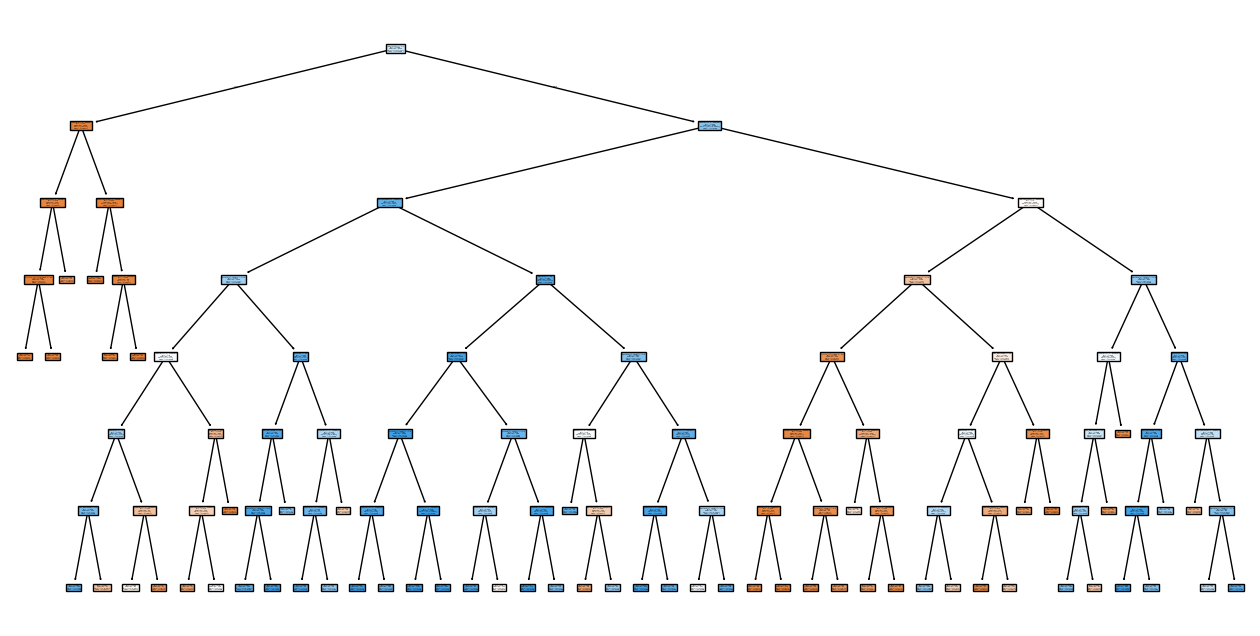

In [22]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(16,8))
plot_tree(dt_tuned, filled=True, feature_names=X.columns, class_names=["Rejected", "Approved"])
plt.show()


9. Test is with a mock input

In [29]:
mock_input = pd.DataFrame([{
    'Gender': 1,
    'Married': 1,
    'Dependents': 2,
    'Education': 1,
    'Self_Employed': 0,
    'ApplicantIncome': 5500,
    'CoapplicantIncome': 1500,
    'LoanAmount': 150,
    'Loan_Amount_Term': 360,
    'Credit_History': 1,
    'Employment_Length': 6,
    'Age': 32,
    'Property_Area_Semiurban': 0,
    'Property_Area_Urban': 1
}])

# Make prediction
prediction = dt_tuned.predict(mock_input)
print("Predicted Loan Status:", "Approved" if prediction[0] == 1 else "Rejected")

Predicted Loan Status: Rejected
